# Quick Learning Curve Sandbox

This notebook keeps the workflow minimal: it reuses `DataPreparation` for preprocessing/poisoning, calls the training utilities from `model.py`, and overlays the validation learning curves for multiple FrogDQ modes (default: `none`, `inertia`, `samplewise`, `dirichlet`, `q`).
Provide the dataset/poisoning parameters in the configuration cell, run the last cell, and you will get an on-the-fly plot plus a short metric summary.
If you plug in a brand-new dataset, make sure it follows the same schema handled in `DataPreparation` (or extend that class with your loader) so the preprocessing and poisoning steps stay compatible.


In [1]:
from typing import Sequence, Tuple, Dict, Optional

import matplotlib.pyplot as plt
import torch

from DataPreparation import DataPreparation
from model import build_model, train, parse_frogdq_mode


def _detect_device() -> torch.device:
    """Pick the best available accelerator for local experiments."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = _detect_device()
print(f"Using device: {DEVICE}")


Using device: mps


In [51]:
import numpy as np
import inspect
from sklearn import datasets
from sklearn.utils.multiclass import type_of_target
from sklearn.datasets import fetch_openml
import openml
import pandas as pd


# -------------------------------
# Utility: multiclass → binary
# -------------------------------
def binarize_majority_vs_rest(y):
    y = np.asarray(y)
    classes, counts = np.unique(y, return_counts=True)
    majority = classes[np.argmax(counts)]
    return (y == majority).astype(int), majority


# -------------------------------
# 1. Iterate sklearn datasets
# -------------------------------
def iter_sklearn_tabular_datasets(
    verbose=False,
    min_samples=0,
    max_samples=None,
    min_features=0,
    max_features=None,
    allow_multiclass_binarization=True,
    allow_missing=False,  # 👈 NEW PARAM
):
    skip = {
        "load_diabetes",            # regression
        "fetch_california_housing", # regression
        "fetch_20newsgroups",
        "fetch_rcv1",
        "fetch_kddcup99",
        "fetch_lfw_people",
        "fetch_lfw_pairs",
        "fetch_olivetti_faces",
        "load_sample_images",
        "load_sample_image",
    }

    for name, func in inspect.getmembers(datasets, inspect.isfunction):
        if not (name.startswith("load_") or name.startswith("fetch_")):
            continue
        if name in skip:
            continue

        if verbose:
            print(f"[sklearn] trying {name}")

        try:
            bunch = func()
        except Exception as e:
            if verbose:
                print(f"  -> error calling {name}: {repr(e)}")
            continue

        X = getattr(bunch, "data", None)
        y = getattr(bunch, "target", None)
        if X is None or y is None:
            if verbose:
                print("  -> missing data/target, skipping")
            continue

        X = np.asarray(X)
        y = np.asarray(y)

        # Must be tabular
        if X.ndim != 2:
            if verbose:
                print(f"  -> X.ndim={X.ndim} (not 2), skipping")
            continue

        # Handle missing values (for numeric dtypes)
        if not allow_missing:
            X_has_nan = np.issubdtype(X.dtype, np.number) and np.isnan(X).any()
            y_has_nan = np.issubdtype(y.dtype, np.number) and np.isnan(y).any()
            if X_has_nan or y_has_nan:
                if verbose:
                    print(f"  -> contains missing values (X_nan={X_has_nan}, y_nan={y_has_nan}), skipping")
                continue

        n_samples, n_features = X.shape

        # Apply constraints
        if n_samples < min_samples:
            if verbose:
                print(f"  -> n_samples={n_samples} < min_samples={min_samples}, skipping")
            continue
        if max_samples is not None and n_samples > max_samples:
            if verbose:
                print(f"  -> n_samples={n_samples} > max_samples={max_samples}, skipping")
            continue
        if n_features < min_features:
            if verbose:
                print(f"  -> n_features={n_features} < min_features={min_features}, skipping")
            continue
        if max_features is not None and n_features > max_features:
            if verbose:
                print(f"  -> n_features={n_features} > max_features={max_features}, skipping")
            continue

        tgt = type_of_target(y)
        u = np.unique(y)

        if tgt == "binary":
            # Skip if any of the classes is NaN
            if any(pd.isna(u)):
                if verbose:
                    print("  -> one of the classes is NaN, skipping")
                continue

            # Handle string targets (numpy strings, python str, or object dtype)
            if (
                np.issubdtype(u.dtype, np.str_)
                or u.dtype == object
                or any(isinstance(c, str) for c in u)
            ):
                if u.size == 2:
                    label_to_int = {u[0]: 0, u[1]: 1}
                else:
                    label_to_int = {cls: i for i, cls in enumerate(u)}
                y = np.vectorize(label_to_int.get)(y)

            if verbose:
                print(f"  -> ACCEPTED (binary), shape={X.shape}")
            yield f"sk_{name}", X, y

        elif tgt == "multiclass" and allow_multiclass_binarization:
            y_bin, maj = binarize_majority_vs_rest(y)
            if verbose:
                print(
                    f"  -> multiclass -> binarized majority-vs-rest "
                    f"(majority class={maj}), shape={X.shape}"
                )
            yield f"sk_{name}_majvsrest", X, y_bin

        else:
            if verbose:
                print(f"  -> target_type={tgt}, not accepted")
            continue


# -------------------------------
# 2. Iterate OpenML datasets
# -------------------------------
def iter_openml_tabular_datasets(
    verbose=False,
    min_samples=0,
    max_samples=None,
    min_features=0,
    max_features=None,
    allow_multiclass_binarization=True,
    max_datasets=None,
    allow_missing=False,   
):

    # Fetch metadata table from OpenML
    meta = openml.datasets.list_datasets(output_format="dataframe")

    # Base filters
    df = meta[
        (meta["status"] == "active") &
        (meta["NumberOfClasses"] >= 2) &
        (meta["NumberOfInstances"] >= min_samples) &
        (meta["NumberOfFeatures"] >= min_features)
    ]

    if max_samples is not None:
        df = df[df["NumberOfInstances"] <= max_samples]
    if max_features is not None:
        df = df[df["NumberOfFeatures"] <= max_features]

    # Filter out datasets with missing values at metadata level (if requested)
    if not allow_missing and "NumberOfMissingValues" in df.columns:
        df = df[df["NumberOfMissingValues"] == 0]

    if verbose:
        print(f"OpenML: {len(df)} datasets match metadata constraints ")

    count = 0

    for did, row in df.iterrows():
        if max_datasets is not None and count >= max_datasets:
            return

        try:
            dataset = openml.datasets.get_dataset(did)

            # Use dataframe format to easily inspect NaNs
            X, y, categorical, attribute_names = dataset.get_data(
                target=dataset.default_target_attribute,
                dataset_format="dataframe",
                include_ignore_attribute=True
            )
        except Exception as e:
            if verbose:
                print(f"Skipping dataset {did} ({row['name']}):", repr(e))
            continue

        # Check for missing values at data level (robust)
        if not allow_missing:
            has_missing = X.isna().values.any() or pd.isna(y).values.any()
            if has_missing:
                if verbose:
                    print(f"Skipping {did} ({row['name']}): contains missing values")
                continue

        # Convert to numpy for downstream pipelines
        if hasattr(X, "to_numpy"):
            X = X.to_numpy()
        else:
            X = np.asarray(X)

        y = np.asarray(y)

        if X.ndim != 2:
            continue

        tgt = type_of_target(y)
        u = np.unique(y)

        if tgt == "binary" or u.size <= 2:
            print("Binary Target")

            # Skip if any of the classes is NaN
            if any(pd.isna(u)):
                if verbose:
                    print(f"Skipping {did} ({row['name']}): one of the classes is NaN")
                continue

            print(type(u[0]))

            # Handle string targets (numpy strings, python str, or object dtype)
            if (
                np.issubdtype(u.dtype, np.str_)
                or u.dtype == object
                or any(isinstance(c, str) for c in u)
            ):
                if u.size == 2:
                    label_to_int = {u[0]: 0, u[1]: 1}
                else:
                    label_to_int = {cls: i for i, cls in enumerate(u)}
                y = np.vectorize(label_to_int.get)(y)

            yield f"oml_{did}_{row['name']}", X, y
            count += 1

        elif (tgt == "multiclass" or u.size > 2) and allow_multiclass_binarization:
            print("Multiclass Target")
            classes, counts = np.unique(y, return_counts=True)
            majority = classes[np.argmax(counts)]
            y_bin = (y == majority).astype(int)
            yield f"oml_{did}_{row['name']}_majvsrest", X, y_bin


# -------------------------------
# 3. Unified iterator: sklearn + OpenML
# -------------------------------
def iter_all_binary_tabular_datasets(
    verbose=False,
    min_samples=0,
    max_samples=None,
    min_features=0,
    max_features=None,
    allow_multiclass_binarization=True,
    allow_missing=False,
    max_openml=None,
):
    # sklearn
    for name, X, y in iter_sklearn_tabular_datasets(
        verbose=verbose,
        min_samples=min_samples,
        max_samples=max_samples,
        min_features=min_features,
        max_features=max_features,
        allow_multiclass_binarization=allow_multiclass_binarization,
        allow_missing=allow_missing
    ):
        yield name, X, y

    # OpenML
    for name, X, y in iter_openml_tabular_datasets(
        verbose=verbose,
        min_samples=min_samples,
        max_samples=max_samples,
        min_features=min_features,
        max_features=max_features,
        allow_multiclass_binarization=allow_multiclass_binarization,
        max_datasets=max_openml,
        allow_missing=allow_missing
    ):
        yield name, X, y

In [52]:
for ds_name, X, y in iter_all_binary_tabular_datasets(verbose=True):
    print(f"\n=== Running on {ds_name} ===")
    print(f"X shape: {X.shape}, y shape: {y.shape}")
    print(f"X type: {type(X)}, y type: {type(y)}")
    print(f"X sample:\n{X[:5]}")
    print(f"y sample:\n{y[:5]}")

[sklearn] trying fetch_20newsgroups_vectorized
  -> X.ndim=0 (not 2), skipping
[sklearn] trying fetch_covtype
  -> multiclass -> binarized majority-vs-rest (majority class=2), shape=(581012, 54)

=== Running on sk_fetch_covtype_majvsrest ===
X shape: (581012, 54), y shape: (581012,)
X type: <class 'numpy.ndarray'>, y type: <class 'numpy.ndarray'>
X sample:
[[ 2.596e+03  5.100e+01  3.000e+00  2.580e+02  0.000e+00  5.100e+02
   2.210e+02  2.320e+02  1.480e+02  6.279e+03  1.000e+00  0.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   1.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00]
 [ 2.590e+03  5.600e+01  2.0

Binary Target
<class 'str'>

=== Running on oml_3_kr-vs-kp ===
X shape: (3196, 36), y shape: (3196,)
X type: <class 'numpy.ndarray'>, y type: <class 'numpy.ndarray'>
X sample:
[['f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'l' 'f' 'n' 'f' 'f' 't'
  'f' 'f' 'f' 'f' 'f' 'f' 'f' 't' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 't' 't' 'n']
 ['f' 'f' 'f' 'f' 't' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'l' 'f' 'n' 'f' 'f' 't'
  'f' 'f' 'f' 'f' 'f' 'f' 'f' 't' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 't' 't' 'n']
 ['f' 'f' 'f' 'f' 't' 'f' 't' 'f' 'f' 'f' 'f' 'f' 'l' 'f' 'n' 'f' 'f' 't'
  'f' 'f' 'f' 'f' 'f' 'f' 'f' 't' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 't' 't' 'n']
 ['f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 't' 'f' 'f' 'f' 'l' 'f' 'n' 'f' 'f' 't'
  'f' 'f' 'f' 't' 'f' 'f' 'f' 't' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 't' 't' 'n']
 ['f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'l' 'f' 'n' 'f' 'f' 't'
  'f' 'f' 'f' 'f' 'f' 't' 'f' 't' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 't' 't' 'n']]
y sample:
[1 1 1 1 1]


Multiclass Target

=== Running on oml_6_letter_majvsrest ===
X shape: (20000, 16), y shape: (20000,)
X type: <class 'numpy.ndarray'>, y type: <class 'numpy.ndarray'>
X sample:
[[ 2  4  4  3  2  7  8  2  9 11  7  7  1  8  5  6]
 [ 4  7  5  5  5  5  9  6  4  8  7  9  2  9  7 10]
 [ 7 10  8  7  4  8  8  5 10 11  2  8  2  5  5 10]
 [ 4  9  5  7  4  7  7 13  1  7  6  8  3  8  0  8]
 [ 6  7  8  5  4  7  6  3  7 10  7  9  3  8  3  7]]
y sample:
[0 0 0 0 0]


Multiclass Target

=== Running on oml_10_lymph_majvsrest ===
X shape: (148, 18), y shape: (148,)
X type: <class 'numpy.ndarray'>, y type: <class 'numpy.ndarray'>
X sample:
[['arched' 'yes' 'no' 'no' 'no' 'no' 'no' 'yes' 1 4 'round' 'lac_central'
  'lacunar' 'stripped' 'vesicles' 'yes' 'yes' 5]
 ['displaced' 'yes' 'no' 'no' 'yes' 'yes' 'no' 'yes' 1 3 'round'
  'lac_central' 'lacunar' 'diluted' 'vesicles' 'yes' 'yes' 3]
 ['deformed' 'no' 'no' 'no' 'yes' 'yes' 'yes' 'no' 3 1 'bean' 'lacunar'
  'no' 'diluted' 'vesicles' 'no' 'no' 7]
 ['arched' 'no' 'no' 'no' 'no' 'yes' 'no' 'yes' 1 2 'oval' 'lac_margin'
  'lac_margin' 'drop_like' 'vesicles' 'no' 'yes' 1]
 ['arched' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 1 2 'round' 'lac_margin'
  'lac_margin' 'faint' 'vesicles' 'no' 'no' 1]]
y sample:
[0 0 0 0 1]


Multiclass Target

=== Running on oml_11_balance-scale_majvsrest ===
X shape: (625, 4), y shape: (625,)
X type: <class 'numpy.ndarray'>, y type: <class 'numpy.ndarray'>
X sample:
[[1 1 1 1]
 [1 1 1 2]
 [1 1 1 3]
 [1 1 1 4]
 [1 1 1 5]]
y sample:
[0 0 0 0 0]


Multiclass Target

=== Running on oml_12_mfeat-factors_majvsrest ===
X shape: (2000, 216), y shape: (2000,)
X type: <class 'numpy.ndarray'>, y type: <class 'numpy.ndarray'>
X sample:
[[ 98 236 531 ...  15  12  13]
 [121 193 607 ...  13  15  11]
 [115 141 590 ...  14  13   6]
 [ 90 122 627 ...  12  15   9]
 [157 167 681 ...  15  13  13]]
y sample:
[1 1 1 1 1]


Multiclass Target

=== Running on oml_14_mfeat-fourier_majvsrest ===
X shape: (2000, 76), y shape: (2000,)
X type: <class 'numpy.ndarray'>, y type: <class 'numpy.ndarray'>
X sample:
[[0.06588172 0.19731169 0.10382563 0.27036171 0.61607757 0.03585575
  0.42457192 0.08970119 0.36777339 0.03706516 0.07594178 0.26390595
  0.07790313 0.37200891 0.21948485 0.05532691 0.10890633 0.12775213
  0.11405136 0.01858087 0.10262683 0.17268198 0.0730332  0.14034402
  0.13219889 0.07601515 0.03251728 0.12883987 0.12052641 0.01661452
  0.10258255 0.1016249  0.06572986 0.03521252 0.07900934 0.08377258
  0.02149083 0.12162476 0.06751158 0.03377662 0.09901323 0.05940796
  0.08128562 0.05234493 0.09049952 0.06358191 0.08110426 0.05910051
  0.09723591 0.04157573 0.08351457 0.04237858 0.08296503 0.07717036
  0.11673209 0.03476068 0.10948465 0.01642286 0.09935212 0.11376267
  0.08637167 0.16765423 0.10628061 0.12578294 0.09067476 0.08125645
  0.12344814 0.11337439 0.07434256 0.2816663  0.0677952  0.34418162
  

Multiclass Target

=== Running on oml_16_mfeat-karhunen_majvsrest ===
X shape: (2000, 64), y shape: (2000,)
X type: <class 'numpy.ndarray'>, y type: <class 'numpy.ndarray'>
X sample:
[[-1.02970076e+01 -1.16667891e+01  1.15606690e+01 -2.08131576e+00
   4.04465580e+00  4.08681488e+00 -2.55807209e+00 -8.47693539e+00
   2.13813472e+00  3.50308204e+00 -6.40735600e-02  9.83302120e-01
   2.00134420e+00  1.47868252e+00 -4.02920720e-01  1.60976803e+00
  -2.62792277e+00  2.74171543e+00 -2.28338909e+00  1.23970795e+00
  -1.82724667e+00 -1.58161497e+00  2.02786493e+00 -3.94052030e-01
  -1.44615936e+00 -6.03834090e-01  2.47522449e+00 -1.09659052e+00
   1.31142235e+00 -3.46206190e-01 -8.22163940e-01 -1.01209509e+00
   1.62056935e+00  2.62892780e-01  4.57351510e-01  1.36522615e+00
  -1.12144470e+00 -7.11748000e-02 -9.14878250e-01 -1.44009924e+00
  -2.19252634e+00  8.30108280e-01  4.52904880e-01  1.08559155e+00
   1.96038878e+00 -8.77156140e-01  3.77651390e-01 -3.07988410e-01
  -1.79443400e-02  4.4264

KeyboardInterrupt: 

In [2]:
def prepare_dataset(
    dataset_name: str,
    *,
    splitting_perc_train_test: float,
    splitting_perc_test_val: float,
    features_percentage: float,
    poisoning_percentage: float,
    random_state: int,
) -> Dict:
    """Helper that wraps DataPreparation so we only need to provide the name."""
    prep = DataPreparation(dataset_name=dataset_name)
    prep.load()
    return prep.run_preprocessing(
        splitting_perc_train_test=splitting_perc_train_test,
        splitting_perc_test_val=splitting_perc_test_val,
        features_percentage=features_percentage,
        poisoning_percentage=poisoning_percentage,
        random_state=random_state,
    )


def plot_learning_curves(mode_histories: Sequence[Tuple[str, dict]], metric: str = "val_bal_acc") -> None:
    """Overlay validation learning curves for each FrogDQ mode."""
    titles = {
        "val_loss": "Validation loss",
        "val_acc": "Validation accuracy",
        "val_bal_acc": "Validation balanced accuracy",
        "val_f1": "Validation F1",
        "val_auc": "Validation AUC",
    }
    ylabel = titles.get(metric, metric.replace("_", " " ).title())

    if not mode_histories:
        print("No histories available for plotting.")
        return

    plt.figure(figsize=(10, 6))
    plotted = False
    for mode_name, history in mode_histories:
        values = history.get(metric, [])
        if not values:
            continue
        epochs = range(1, len(values) + 1)
        plt.plot(epochs, values, label=mode_name, linewidth=2.0)
        plotted = True

    if not plotted:
        print(f"Metric '{metric}' not found in the available histories.")
        return

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(f"Validation curve — {ylabel}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_learning_curve_experiment(
    *,
    dataset_name: str,
    poisoning_key: str,
    frogdq_modes: Sequence[str],
    features_percentage: float = 0.2,
    poisoning_percentage: float = 0.2,
    splitting_perc_train_test: float = 0.8,
    splitting_perc_test_val: float = 0.5,
    random_state: int = 42,
    epochs: int = 100,
    batch_size: int = 256,
    lr: float = 1e-3,
    optimizer: str = "sgd",
    model_arch: str = "mlp",
    metric: str = "val_bal_acc",
    show_training_logs: bool = False,
    train_overrides: Optional[Dict] = None,
) -> Dict[str, dict]:
    """
    Run preprocessing once, train over the requested FrogDQ modes, plot the curves,
    and return the raw histories (keyed by canonical mode name).
    """
    data_bundle = prepare_dataset(
        dataset_name,
        splitting_perc_train_test=splitting_perc_train_test,
        splitting_perc_test_val=splitting_perc_test_val,
        features_percentage=features_percentage,
        poisoning_percentage=poisoning_percentage,
        random_state=random_state,
    )

    available_splits = sorted(
        k for k, v in data_bundle.items() if isinstance(v, dict) and 'X_train' in v
    )
    if poisoning_key not in data_bundle:
        raise ValueError(
            f"Poisoning split '{poisoning_key}' not found. Choose among: {available_splits}"
        )

    split = data_bundle[poisoning_key]
    class_count = int(torch.unique(data_bundle['y_train']).numel())
    mode_histories: list[Tuple[str, dict]] = []
    summaries: list[Tuple[str, Optional[float]]] = []
    extra_train_args = dict(train_overrides or {})

    for requested_mode in frogdq_modes:
        modules = parse_frogdq_mode(requested_mode)
        canonical_name = modules.canonical
        active_modules = set(modules.active)
        requested_modules = set(modules.requested)
        use_gate = "inertia" in active_modules

        q_vec = split['q'] if use_gate else None
        r_vec = split.get('r') if "samplewise" in active_modules else None
        gate_init_vector = split['q'].tolist() if "q" in requested_modules else None

        print(f"Training mode: {canonical_name}")
        model = build_model(
            input_dim=split['X_train'].shape[1],
            output_dim=class_count,
            arch=model_arch,
            use_frogdq=use_gate,
            gate_init_vector=gate_init_vector,
            random_state=random_state,
        )

        history = train(
            model=model,
            X_train=split['X_train'],
            y_train=data_bundle['y_train'],
            X_val=split['X_val'],
            y_val=data_bundle['y_val'],
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            optimizer=optimizer,
            frogdq_mode=canonical_name,
            q_vec=q_vec,
            r_vec=r_vec,
            device=DEVICE,
            verbose=show_training_logs,
            random_state=random_state,
            **extra_train_args,
        )

        mode_histories.append((canonical_name, history))
        metric_values = history.get(metric, [])
        summaries.append((canonical_name, metric_values[-1] if metric_values else None))

    plot_learning_curves(mode_histories, metric=metric)

    print(f"\nFinal {metric} per mode:")
    for mode_name, value in summaries:
        if value is None:
            print(f"  - {mode_name}: n/a")
        else:
            print(f"  - {mode_name}: {value:.4f}")

    return {name: history for name, history in mode_histories}


In [6]:
from ucimlrepo import fetch_ucirepo

# fetch dataset 
hcv_data = fetch_ucirepo(id=571) 
  
# data (as pandas dataframes) 
X = hcv_data.data.features 
y = hcv_data.data.targets 

In [7]:
y.value_counts()

Category              
0=Blood Donor             533
3=Cirrhosis                30
1=Hepatitis                24
2=Fibrosis                 21
0s=suspect Blood Donor      7
Name: count, dtype: int64

In [8]:
# ---------------------------------------------------------------------------
# Adjust these dictionaries to point to your dataset and hyper-parameters
# ---------------------------------------------------------------------------
dataset_config = dict(
    dataset_name="bank_marketing",
    poisoning_key="all",  # one of: clean, flipping, noise, nan, all
    features_percentage=0.2,
    poisoning_percentage=0.8,
    splitting_perc_train_test=0.7,
    splitting_perc_test_val=0.5,
    random_state=42,
)

training_config = dict(
    epochs=500,
    batch_size=256,
    lr=0.001,
    optimizer="sgd",
    model_arch="mlp",
    metric="val_f1",
    show_training_logs=True,
)

# Extra keyword arguments passed straight to model.train (optional)
train_overrides = dict(
    lambda_prox=0.1,
    frog_temp_tau=2.0,
    frog_temp_eta=1.01,
)

frogdq_modes = ["none", "inertia", "samplewise", "dirichlet"]


/Users/mattia.sabella/PhD - PoliMi/Frog-DQ/Repository/FrogDQ.Federated_Proximal_Gating_with_Data_Quality/DataPreparation.py:99: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({"yes": 1, "no": 0})
/Users/mattia.sabella/PhD - PoliMi/Frog-DQ/Repository/FrogDQ.Federated_Proximal_Gating_with_Data_Quality/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/mattia.sabella/PhD - PoliMi/Frog-DQ/Repository/FrogDQ.Federated_Proximal_Gating_with_Data_Quality/data_poisoning.py:286: FutureWarning: Setting an item of incompatible 

Training mode: none


2025-11-27 18:15:46.882 | INFO     | model:train:633 - FrogDQ requested modules: () | active: []
2025-11-27 18:15:46.882 | INFO     | model:train:634 - qvec: None
2025-11-27 18:15:46.882 | INFO     | model:train:636 - Use_frog: False
2025-11-27 18:15:49.289 | INFO     | model:train:794 - Epoch   5 | mode=none | reg_scale=0.000 | lr=1.00e-03 | train: loss=0.4741, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.8070, bal_acc=0.7938, f1=0.6830, auc=0.8750 | val: loss=0.4923, acc=0.7781, bal_acc=0.7890, f1=0.6594, auc=0.8649
2025-11-27 18:15:51.465 | INFO     | model:train:794 - Epoch  10 | mode=none | reg_scale=0.000 | lr=1.00e-03 | train: loss=0.4345, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.8248, bal_acc=0.8090, f1=0.7030, auc=0.8892 | val: loss=0.4544, acc=0.7925, bal_acc=0.8054, f1=0.6757, auc=0.8792
2025-11-27 18:15:53.702 | INFO     | model:train:794 - Epoch  15 | mode=none | reg_scale=0.000

Training mode: inertia


2025-11-27 18:16:51.347 | INFO     | model:train:794 - Epoch   5 | mode=inertia | reg_scale=1.000 | lr=1.00e-03 | train: loss=0.4708, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.8095, bal_acc=0.7949, f1=0.6855, auc=0.8748 | val: loss=0.4899, acc=0.7803, bal_acc=0.7875, f1=0.6606, auc=0.8642
2025-11-27 18:16:53.782 | INFO     | model:train:794 - Epoch  10 | mode=inertia | reg_scale=1.000 | lr=1.00e-03 | train: loss=0.4331, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.8237, bal_acc=0.8094, f1=0.7023, auc=0.8889 | val: loss=0.4523, acc=0.7942, bal_acc=0.8058, f1=0.6771, auc=0.8793
2025-11-27 18:16:56.118 | INFO     | model:train:794 - Epoch  15 | mode=inertia | reg_scale=1.000 | lr=1.00e-03 | train: loss=0.4152, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.8248, bal_acc=0.8179, f1=0.7061, auc=0.8959 | val: loss=0.4344, acc=0.7925, bal_acc=0.8076, f1=0.

Training mode: samplewise


2025-11-27 18:19:33.948 | INFO     | model:train:794 - Epoch   5 | mode=samplewise | reg_scale=1.000 | lr=1.00e-03 | train: loss=0.2260, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.7885, bal_acc=0.7651, f1=0.6587, auc=0.8469 | val: loss=0.5595, acc=0.7545, bal_acc=0.7571, f1=0.6322, auc=0.8364
2025-11-27 18:19:36.671 | INFO     | model:train:794 - Epoch  10 | mode=samplewise | reg_scale=1.000 | lr=1.00e-03 | train: loss=0.1982, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.8102, bal_acc=0.7876, f1=0.6834, auc=0.8698 | val: loss=0.5025, acc=0.7787, bal_acc=0.7806, f1=0.6570, auc=0.8589
2025-11-27 18:19:39.477 | INFO     | model:train:794 - Epoch  15 | mode=samplewise | reg_scale=1.000 | lr=1.00e-03 | train: loss=0.1877, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0000, ratio_loss_prior=0.0000 acc=0.8169, bal_acc=0.7981, f1=0.6926, auc=0.8797 | val: loss=0.4777, acc=0.7875, bal_acc=0.79

Training mode: dirichlet


2025-11-27 18:21:24.838 | INFO     | model:train:794 - Epoch   5 | mode=dirichlet | reg_scale=1.000 | lr=1.00e-03 | train: loss=0.4782, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0076, ratio_loss_prior=0.0159 acc=0.8097, bal_acc=0.7951, f1=0.6857, auc=0.8749 | val: loss=0.4897, acc=0.7803, bal_acc=0.7875, f1=0.6606, auc=0.8643
2025-11-27 18:21:27.252 | INFO     | model:train:794 - Epoch  10 | mode=dirichlet | reg_scale=1.000 | lr=1.00e-03 | train: loss=0.4401, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0073, ratio_loss_prior=0.0166 acc=0.8236, bal_acc=0.8096, f1=0.7022, auc=0.8890 | val: loss=0.4519, acc=0.7940, bal_acc=0.8057, f1=0.6769, auc=0.8795
2025-11-27 18:21:29.655 | INFO     | model:train:794 - Epoch  15 | mode=dirichlet | reg_scale=1.000 | lr=1.00e-03 | train: loss=0.4219, loss_prox=0.0000, ratio_loss_prox=0.0000, loss_prior=0.0071, ratio_loss_prior=0.0167 acc=0.8250, bal_acc=0.8184, f1=0.7064, auc=0.8961 | val: loss=0.4340, acc=0.7931, bal_acc=0.8079,

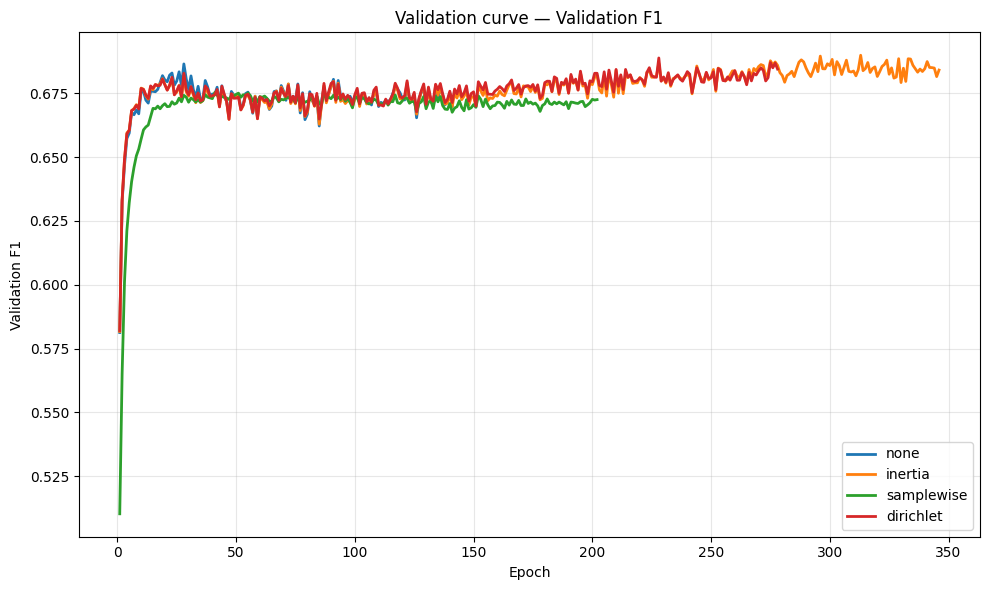


Final val_f1 per mode:
  - none: 0.6702
  - inertia: 0.6841
  - samplewise: 0.6725
  - dirichlet: 0.6845


dict_keys(['none', 'inertia', 'samplewise', 'dirichlet'])

In [9]:
histories = run_learning_curve_experiment(
    frogdq_modes=frogdq_modes,
    train_overrides=train_overrides,
    **dataset_config,
    **training_config,
)

histories.keys()


In [1]:
def gini(x):
    # Ensure the list is sorted
    x = sorted(x)
    n = len(x)
    mean_x = sum(x) / n
    
    # Gini formula
    diff_sum = 0
    for i in range(n):
        for j in range(n):
            diff_sum += abs(x[i] - x[j])
    
    return diff_sum / (2 * n * n * mean_x)

In [4]:
gini([0.5, 0.5, 0.2, 0.2, 0.1])

0.2933333333333333